# 확률의 계산

In [1]:
# 동전 던지기
space = ['앞면', '뒷면']
event = ['앞면']

prob = lambda event, space: len(event)/len(space)
prob(event,space)

0.5

In [2]:
# 주사위 던지기
# 1번 던져 3이 나올 확률
space = [1,2,3,4,5,6]
event = [3]
prob(event,space)


0.16666666666666666

In [3]:
# 주사위에서 짝숭거나 4보다 작은 수가 나올 확률
space = {1,2,3,4,5,6}
event_A = {2,4,6}
event_B = {5,6}

합집합 = event_A | event_B
합집합

{2, 4, 5, 6}

In [4]:
합집합의갯수 = len(합집합)
전체경우의수 = len(space)
확률_1 = 합집합의갯수 / 전체경우의수
확률_1  #짝수 또는 4보다 큰 눈이 나올 확률


0.6666666666666666

In [5]:
# 2이하이거나 5이상인 눈이 나올 확률
event_C = {1, 2}       # 2 이하
event_D = {5, 6}       # 5 이상
union_C_D = event_C | event_D
확률_2 = len(union_C_D) / 전체경우의수
확률_2

0.6666666666666666

In [6]:
# 조건부 확률
sample_space = [1,2,3,4,5,6]
event_A = [2,4,6]
event_B = [2]

P_A = len(event_A)/len(sample_space)  # A일 확률
P_B = len(event_B)/len(sample_space)  # B일 확률
P_B_and_A_else= set(event_A) & set(event_B)  # 교집합의 원소
P_B_and_A_else

{2}

In [7]:
P_B_and_A = len(P_B_and_A_else)/len(sample_space)  # 교집합이 나올 확률
P_B_and_A

0.16666666666666666

In [8]:
# 조건부확률: 짝수일때 2가 나올 확률
# P(B|A) = P(B_and_A)/P_A
P_B_given_A = P_B_and_A / P_A
P_B_given_A

0.3333333333333333

# 우도와 확률값

동전 10번 던지고, 8번 앞면이 나왔다.</br>
우도의계산

In [9]:
from scipy.stats import binom

In [10]:
n = 10
k =8  # 앞면의 횟수
# 가설1 - 공정한 동전일 것이다.
p1 = 0.5 #앞면이 나올 확률 -공정할 경우
p1_likelihood = binom.pmf(k, n, p1)  # 조건, 총사건, 확률

p2 = 0.8
p2_likelihood = binom.pmf(k, n, p2)  # 조건, 총사건, 확률

print(p1_likelihood, p2_likelihood)

0.04394531250000005 0.30198988799999993


가설1의 경우, 앞면이 8번 나올 확률은 4.4%</br>
가설2의 경우, 앞면이 8번 나올 확률은 30.2%</br>

앞면 8번 나오는 관측값은 p = 0.8인 모델이 더 잘 설명한다.(우도가 크다.)

# 기대값
x의 확률들의 평균

In [11]:
x_values = [1,2,3]
P_x = [1/6,3/6,2/6]

exp_values =0
#기대값
for i in range(len(x_values)):
    exp_values += x_values[i] * P_x[i]
    
print(f'기대값: {exp_values:.5f}')

기대값: 2.16667


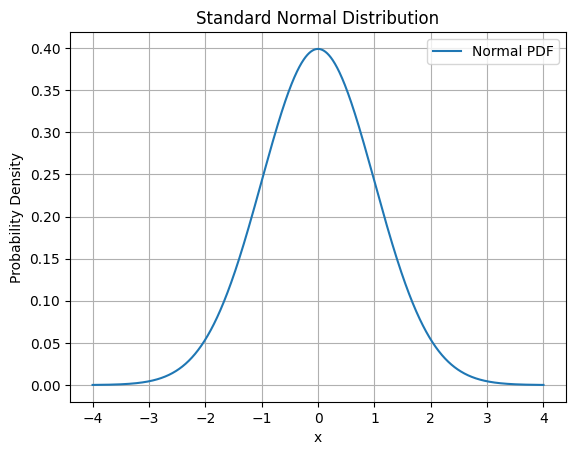

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0       # 평균
sigma = 1    # 표준편차

x = np.linspace(-4, 4, 1000)             # x축 범위
y = norm.pdf(x, loc=mu, scale=sigma)     # 정규분포 PDF 계산

plt.plot(x, y, label="Normal PDF")
plt.title("Standard Normal Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()


# 표집분표

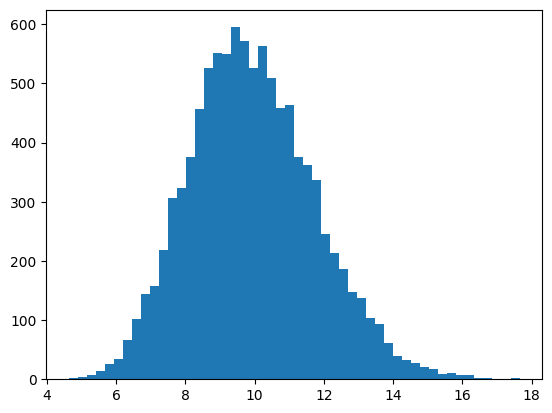

In [13]:
np.random.seed(0)
x_pop = np.random.exponential(scale=10, size= 10000)
sample_mean = [np.mean(np.random.choice(x_pop,size= 30))
               for _ in range(10000)]

plt.hist(sample_mean, bins=50)
plt.show()



In [14]:
mu =100
sigma =10

x1 =110  # z점수를 계산하려고 하는 원래 점수
x2 =125

# z점수 = 원점수- 평균 / 표준편차
z_x1 =(x1 -mu)/sigma
z_x2 =(x2 -mu)/sigma

print(z_x1,z_x2)

1.0 2.5


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
area_z_x1 =norm.cdf(z_x1) - norm.cdf(0)
area_z_x2 = norm.cdf(z_x2) - norm.cdf(0)
diff_area =area_z_x2 -area_z_x1
diff_area

np.float64(0.15244558860568092)

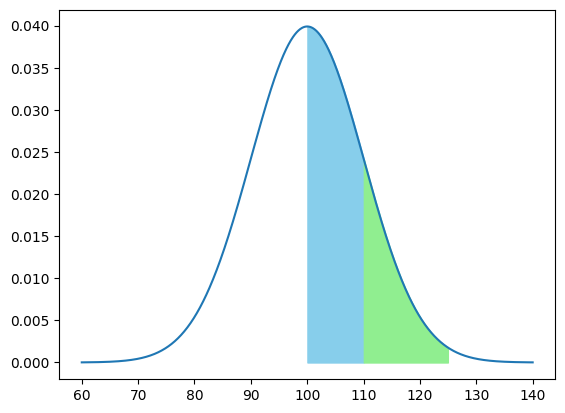

In [16]:
# 시각화
x = np.linspace(mu - 4*sigma, mu+ 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.plot(x,y)
plt.fill_between(x,y, where=(x>=100)&(x<=110), color ='skyblue')
plt.fill_between(x,y, where=(x>110)&(x<=125), color ='lightgreen')
plt.show()